# Seasonal Agriculture Performance Analysis

**Dataset:** `seasonal_agriculture_performance_dataset.csv`

---

This notebook analyzes agricultural performance across three seasons — **Kharif, Rabi and Zaid** — to
uncover seasonal patterns, relationships and differences in farming practices, resource usage,
environmental conditions and economic outcomes.

## 1. Introduction to the Dataset

The dataset represents agricultural activities carried out across different **seasons, geographical
areas and farming conditions**. It contains information related to:

- **Farming practices** — crop, season, irrigation method, farm area
- **Environmental conditions** — rainfall, temperature, humidity, sunlight, soil pH & moisture
- **Resource usage** — fertilizer (N, P, K), pesticide, water used, seed quality
- **Crop production** — yield, production
- **Economic performance** — cost, revenue, profit, market price

### Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming
practices, resource availability and market conditions. Raw agricultural data does not, by itself,
explain how performance changes across seasons. This project investigates **seasonal differences in
agricultural performance** by identifying meaningful patterns, trends, relationships and variations
within the dataset.

### Objective
To analyze agricultural data from different seasons and identify meaningful patterns, trends,
relationships and differences in agricultural performance — through data cleaning, exploratory data
analysis (univariate, bivariate, multivariate), correlation analysis, seasonal comparisons, and
evidence-based conclusions/recommendations.

## 2. Import Libraries

In [77]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display / plotting settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

SEASON_ORDER = ["Kharif", "Rabi", "Zaid"]
SEASON_PALETTE = {"Kharif": "#2E7D32", "Rabi": "#F9A825", "Zaid": "#C62828"}

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Dataset

In [78]:
# Kaggle input path
DATA_PATH = "/kaggle/input/datasets/imranansariiii/seasonal-agriculture-performance-dataset/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully -> {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully -> 4000 rows x 28 columns


## 4. First Look at the Data

Inspecting the top rows, bottom rows and a random sample to get an initial feel for the dataset.

In [79]:
# Top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [80]:
# Bottom 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [81]:
# Random sample of records
df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


## 5. Dataset Shape, Structure & Data Types

In [82]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Column names:")
print(df.columns.tolist())

Shape: 4000 rows, 28 columns

Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [84]:
# Split columns by data type for reference
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):\n{numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")

Numeric columns (22):
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns (6):
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [85]:
# Overview of categorical columns
for c in ["Season", "Crop", "Irrigation_Method", "State"]:
    print(f"--- {c} ({df[c].nunique()} unique values) ---")
    print(df[c].value_counts(), "\n")

--- Season (3 unique values) ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64 

--- Crop (8 unique values) ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64 

--- Irrigation_Method (4 unique values) ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64 

--- State (8 unique values) ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64 



## 6. Missing Value Analysis

In [86]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({"Missing_Count": missing, "Missing_Percent": missing_pct})
missing_summary = missing_summary[missing_summary["Missing_Count"] > 0].sort_values(
    "Missing_Count", ascending=False
)
missing_summary

,Missing_Count,Missing_Percent
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


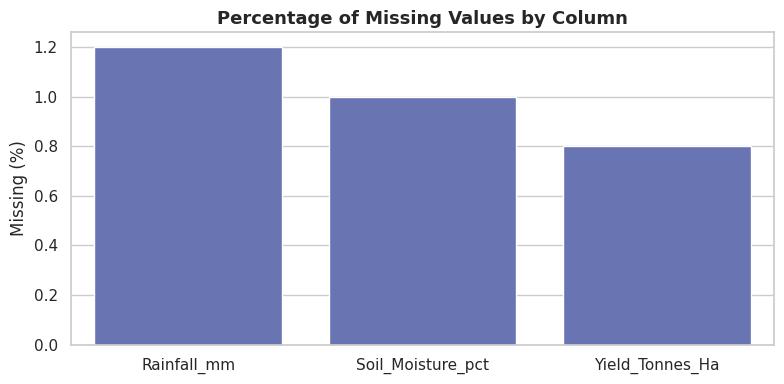

In [87]:
if not missing_summary.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_summary.index, y="Missing_Percent", data=missing_summary, color="#5C6BC0")
    plt.title("Percentage of Missing Values by Column")
    plt.ylabel("Missing (%)")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

## 7. Data Cleaning — Handling Missing Values

In [88]:
cols_to_impute = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]

for col in cols_to_impute:
    df[col] = df.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))

# Safety net: fill any remaining NaNs (e.g. if a whole season-group was NaN) with overall median
for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

print("Missing values remaining after cleaning:")
print(df.isnull().sum().sum())

Missing values remaining after cleaning:
0


## 8. Duplicate Records Check

In [89]:
duplicate_count = df.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_count}")

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate records found — dataset is already clean on this front.")

Number of fully duplicated rows: 0
No duplicate records found — dataset is already clean on this front.


## 9. Descriptive Statistical Analysis

In [90]:
# Numerical summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",600.71,288.43,80.00,370.43,581.00,836.12,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"4,000.00",26.50,6.70,8.00,21.70,26.40,31.20,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [91]:
# Categorical summary statistics
df.describe(include="object").T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


## 10. Outlier Detection (IQR Method)

In [92]:
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Column": col,
        "Lower_Bound": round(lower, 2),
        "Upper_Bound": round(upper, 2),
        "Outlier_Count": count,
        "Outlier_Percentage": round(count / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("Outlier_Count", ascending=False)
outlier_summary.head(10)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


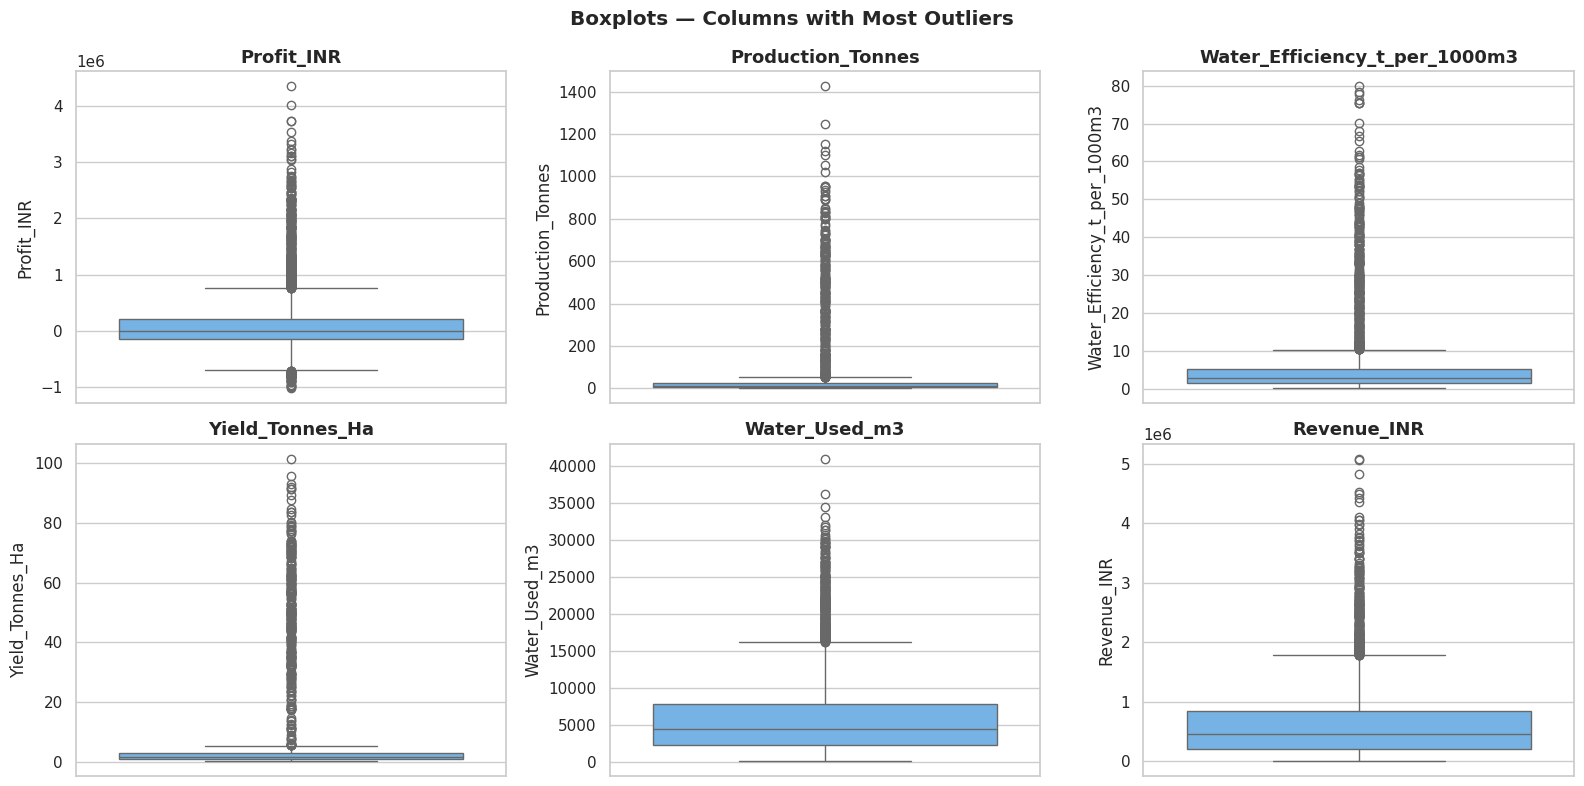

In [93]:
# Visualize the columns with the most outliers
top_outlier_cols = outlier_summary.head(6)["Column"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), top_outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color="#64B5F6")
    ax.set_title(col)
plt.suptitle("Boxplots — Columns with Most Outliers", fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Univariate Analysis

Examining the distribution of individual variables — environmental, resource and economic.

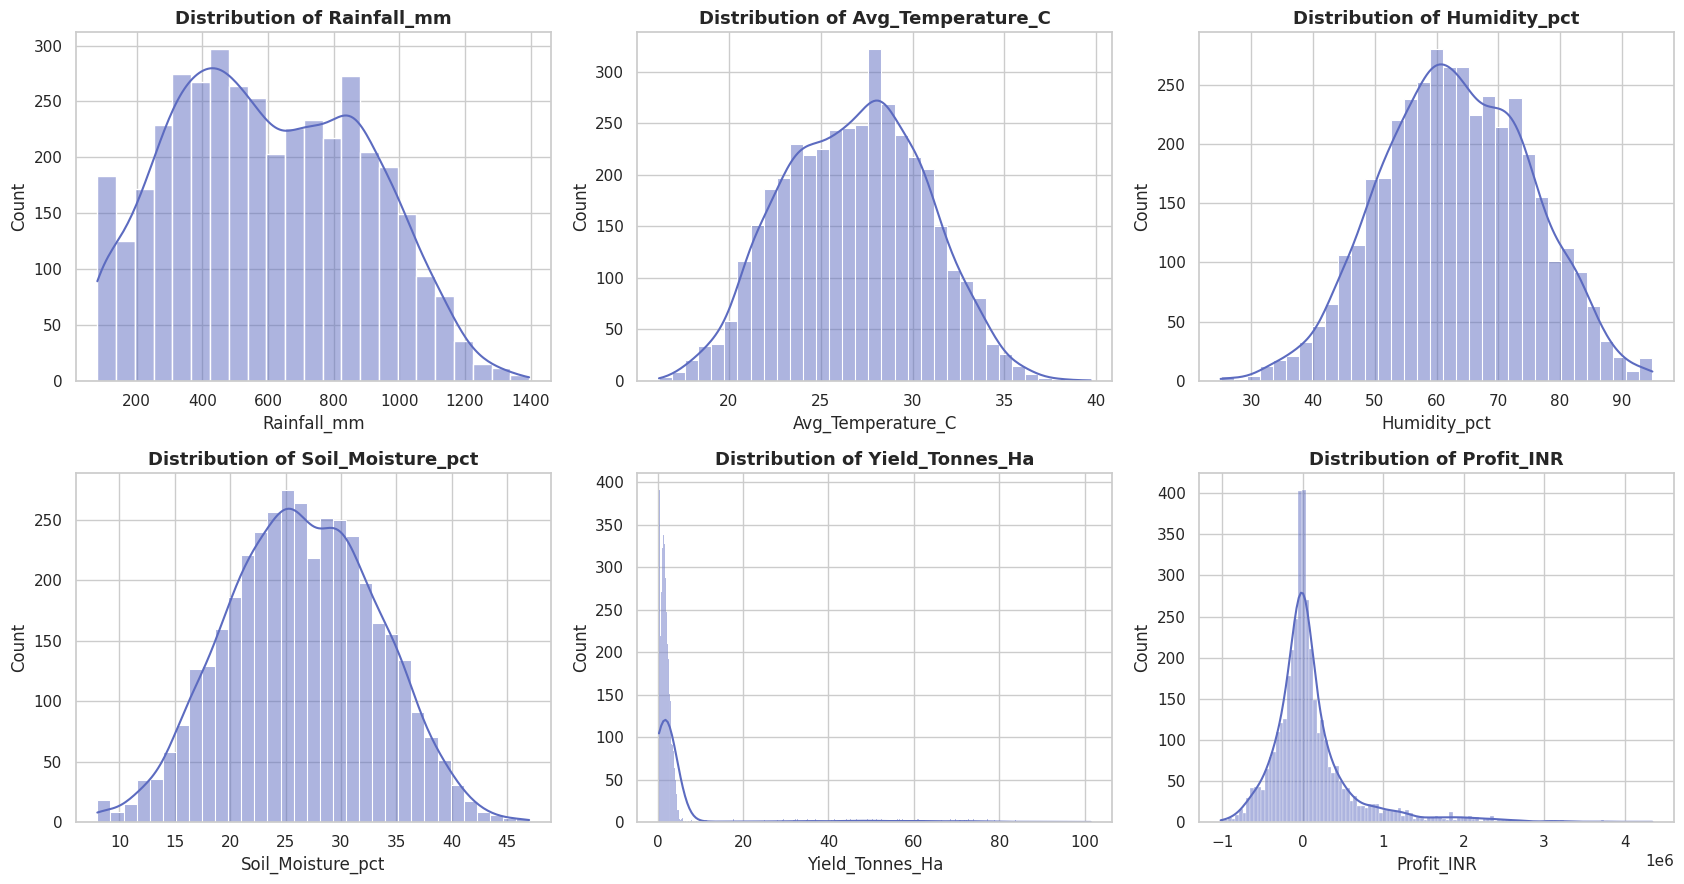

In [94]:
num_features = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
                "Yield_Tonnes_Ha", "Profit_INR"]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.flatten(), num_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#5C6BC0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

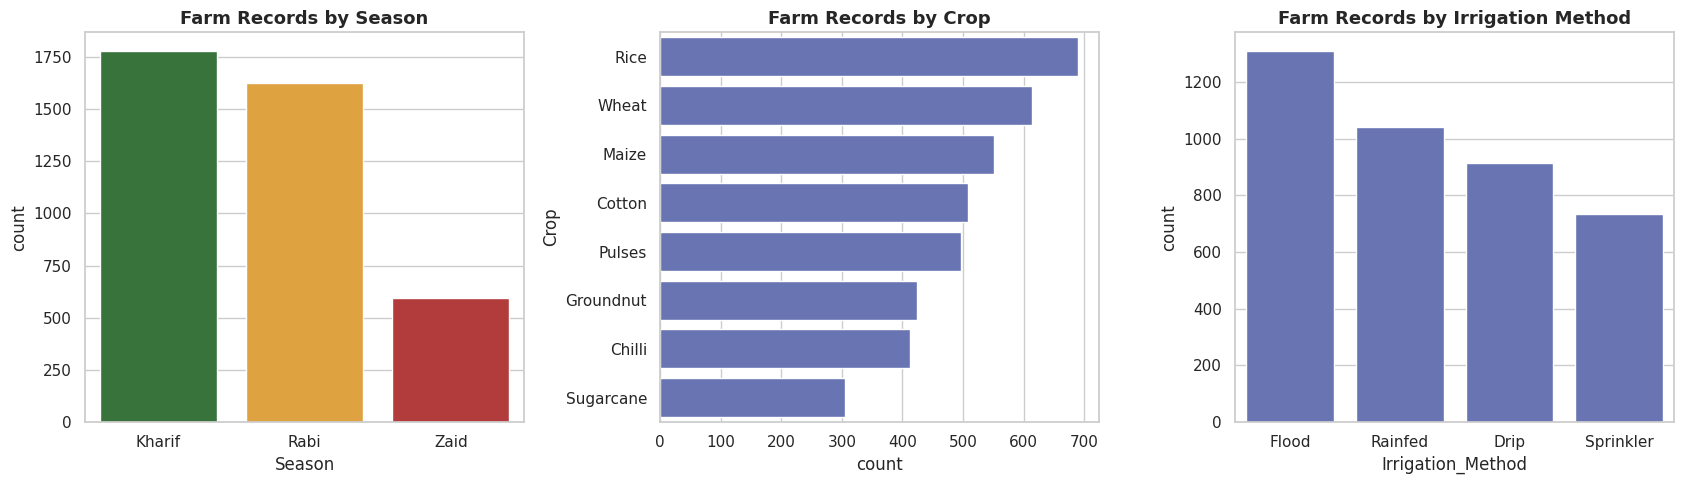

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.countplot(data=df, x="Season", order=SEASON_ORDER, palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title("Farm Records by Season")

sns.countplot(data=df, y="Crop", order=df["Crop"].value_counts().index, ax=axes[1], color="#5C6BC0")
axes[1].set_title("Farm Records by Crop")

sns.countplot(data=df, x="Irrigation_Method", ax=axes[2],
              order=df["Irrigation_Method"].value_counts().index, color="#5C6BC0")
axes[2].set_title("Farm Records by Irrigation Method")

plt.tight_layout()
plt.show()

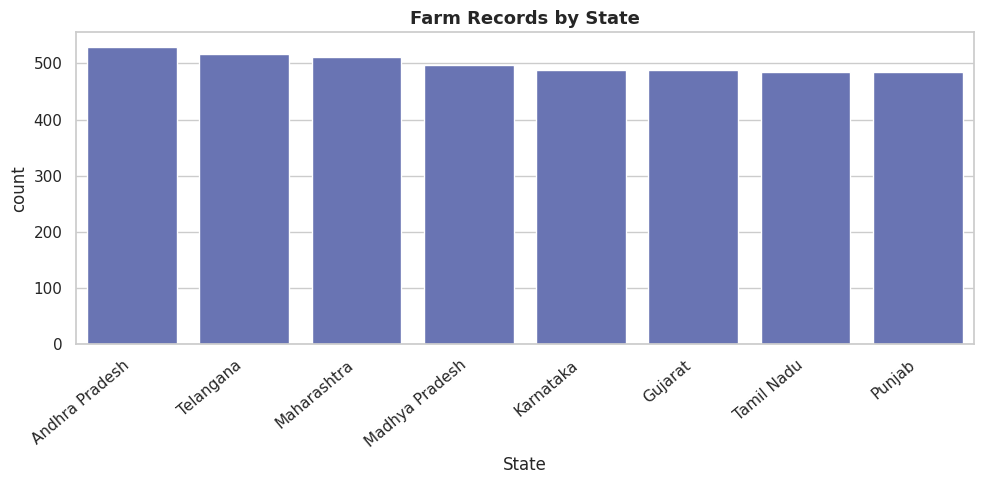

In [96]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="State", order=df["State"].value_counts().index, color="#5C6BC0")
plt.title("Farm Records by State")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

## 12. Bivariate Analysis

Exploring relationships between two variables at a time — mainly how `Season` relates to
yield, profit and risk, and how environmental factors relate to yield.

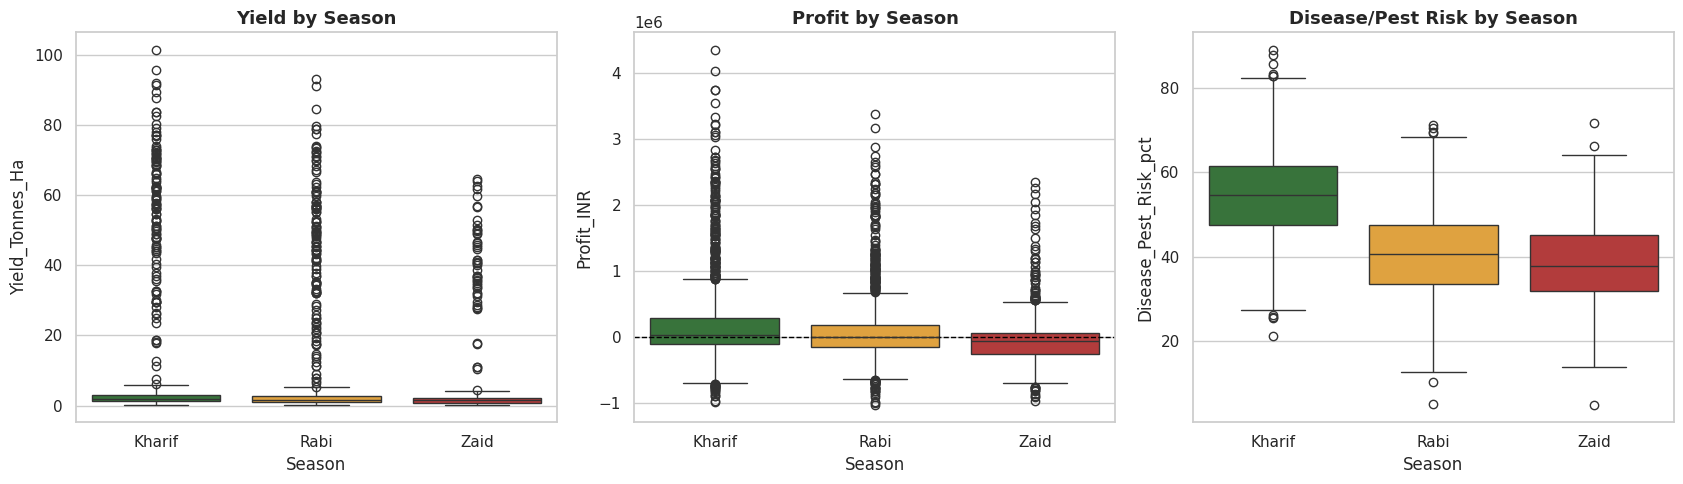

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[0])
axes[0].set_title("Yield by Season")

sns.boxplot(data=df, x="Season", y="Profit_INR", order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[1])
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Profit by Season")

sns.boxplot(data=df, x="Season", y="Disease_Pest_Risk_pct", order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[2])
axes[2].set_title("Disease/Pest Risk by Season")

plt.tight_layout()
plt.show()

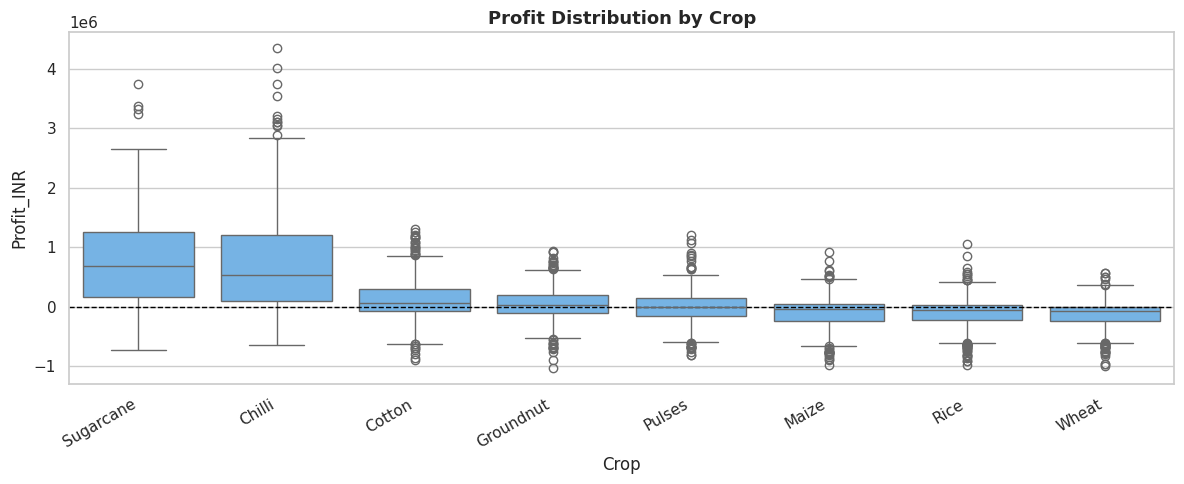

In [98]:
plt.figure(figsize=(12, 5))
order = df.groupby("Crop")["Profit_INR"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Crop", y="Profit_INR", order=order, color="#64B5F6")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Profit Distribution by Crop")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

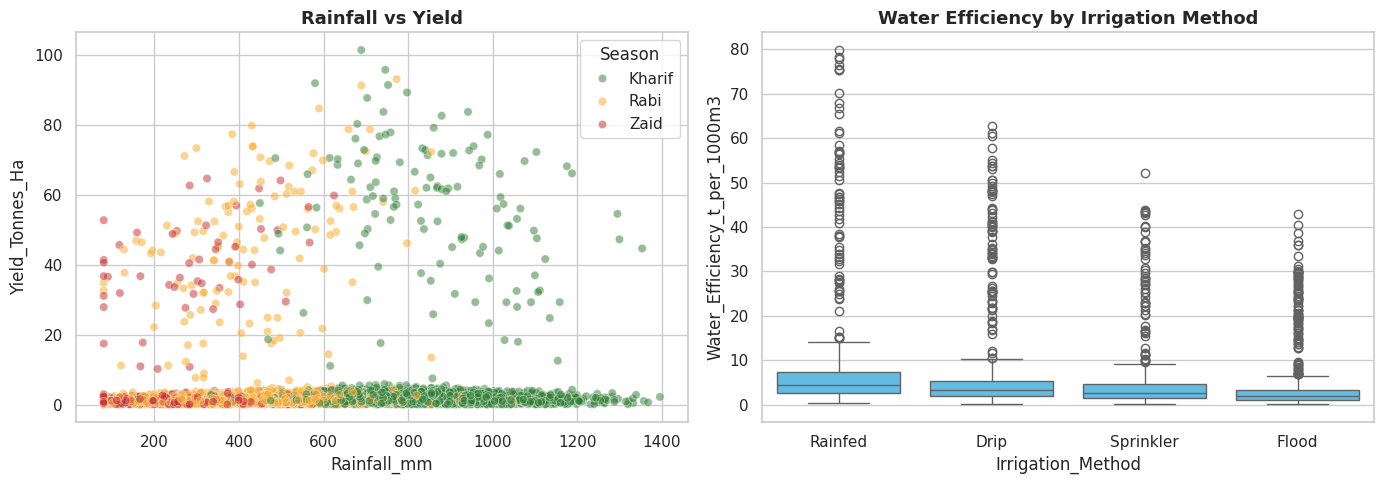

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",
                 palette=SEASON_PALETTE, alpha=0.5, ax=axes[0])
axes[0].set_title("Rainfall vs Yield")

sns.boxplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3",
            order=df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].median()
                    .sort_values(ascending=False).index,
            color="#4FC3F7", ax=axes[1])
axes[1].set_title("Water Efficiency by Irrigation Method")

plt.tight_layout()
plt.show()

## 13. Multivariate Analysis

Looking at three or more variables together to uncover combined effects of season, crop and
resource usage on performance.

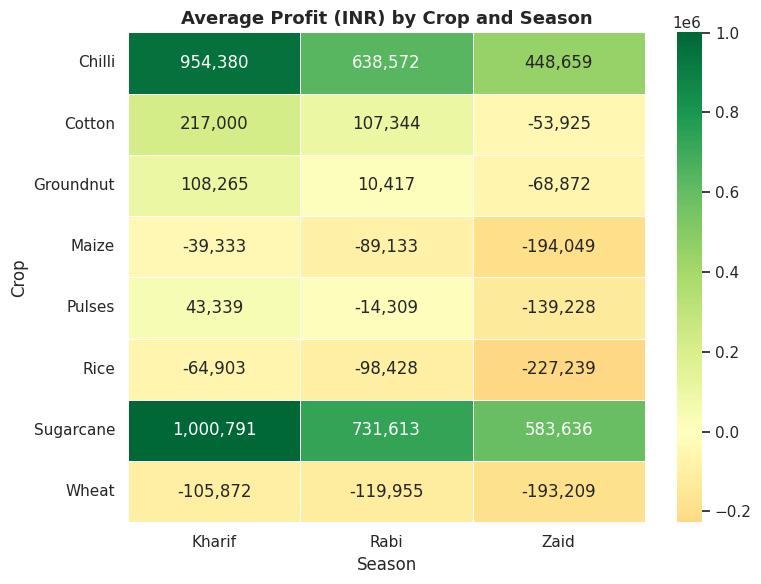

In [100]:
pivot_profit = df.pivot_table(index="Crop", columns="Season", values="Profit_INR",
                               aggfunc="mean", fill_value=0)[SEASON_ORDER]

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_profit, annot=True, fmt=",.0f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Average Profit (INR) by Crop and Season")
plt.tight_layout()
plt.show()

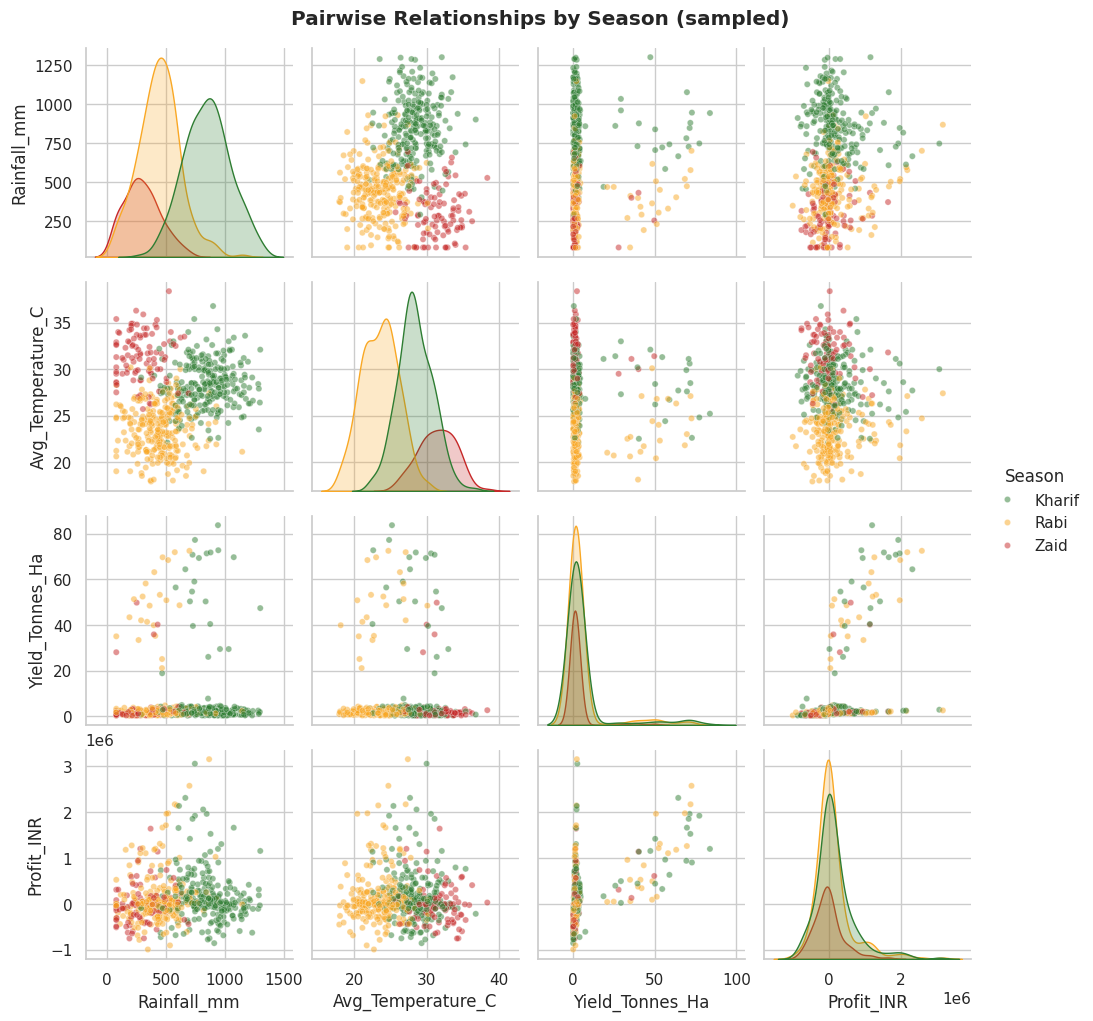

In [101]:
sample_df = df.sample(600, random_state=42)  # sampled for a readable pairplot
pair_cols = ["Rainfall_mm", "Avg_Temperature_C", "Yield_Tonnes_Ha", "Profit_INR", "Season"]

g = sns.pairplot(sample_df[pair_cols], hue="Season", hue_order=SEASON_ORDER,
                  palette=SEASON_PALETTE, plot_kws={"alpha": 0.5, "s": 20}, diag_kind="kde")
g.fig.suptitle("Pairwise Relationships by Season (sampled)", y=1.02, fontweight="bold")
plt.show()

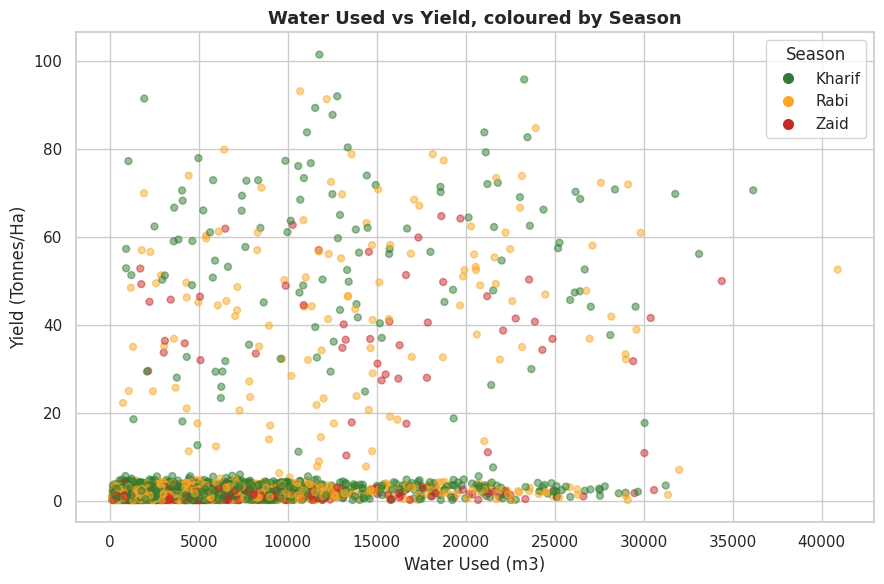

In [102]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df["Water_Used_m3"], df["Yield_Tonnes_Ha"],
                       c=df["Season"].map(SEASON_PALETTE), alpha=0.5, s=25)
plt.xlabel("Water Used (m3)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.title("Water Used vs Yield, coloured by Season")
handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=s)
           for s, c in SEASON_PALETTE.items()]
plt.legend(handles=handles, title="Season")
plt.tight_layout()
plt.show()

## 14. Correlation Analysis

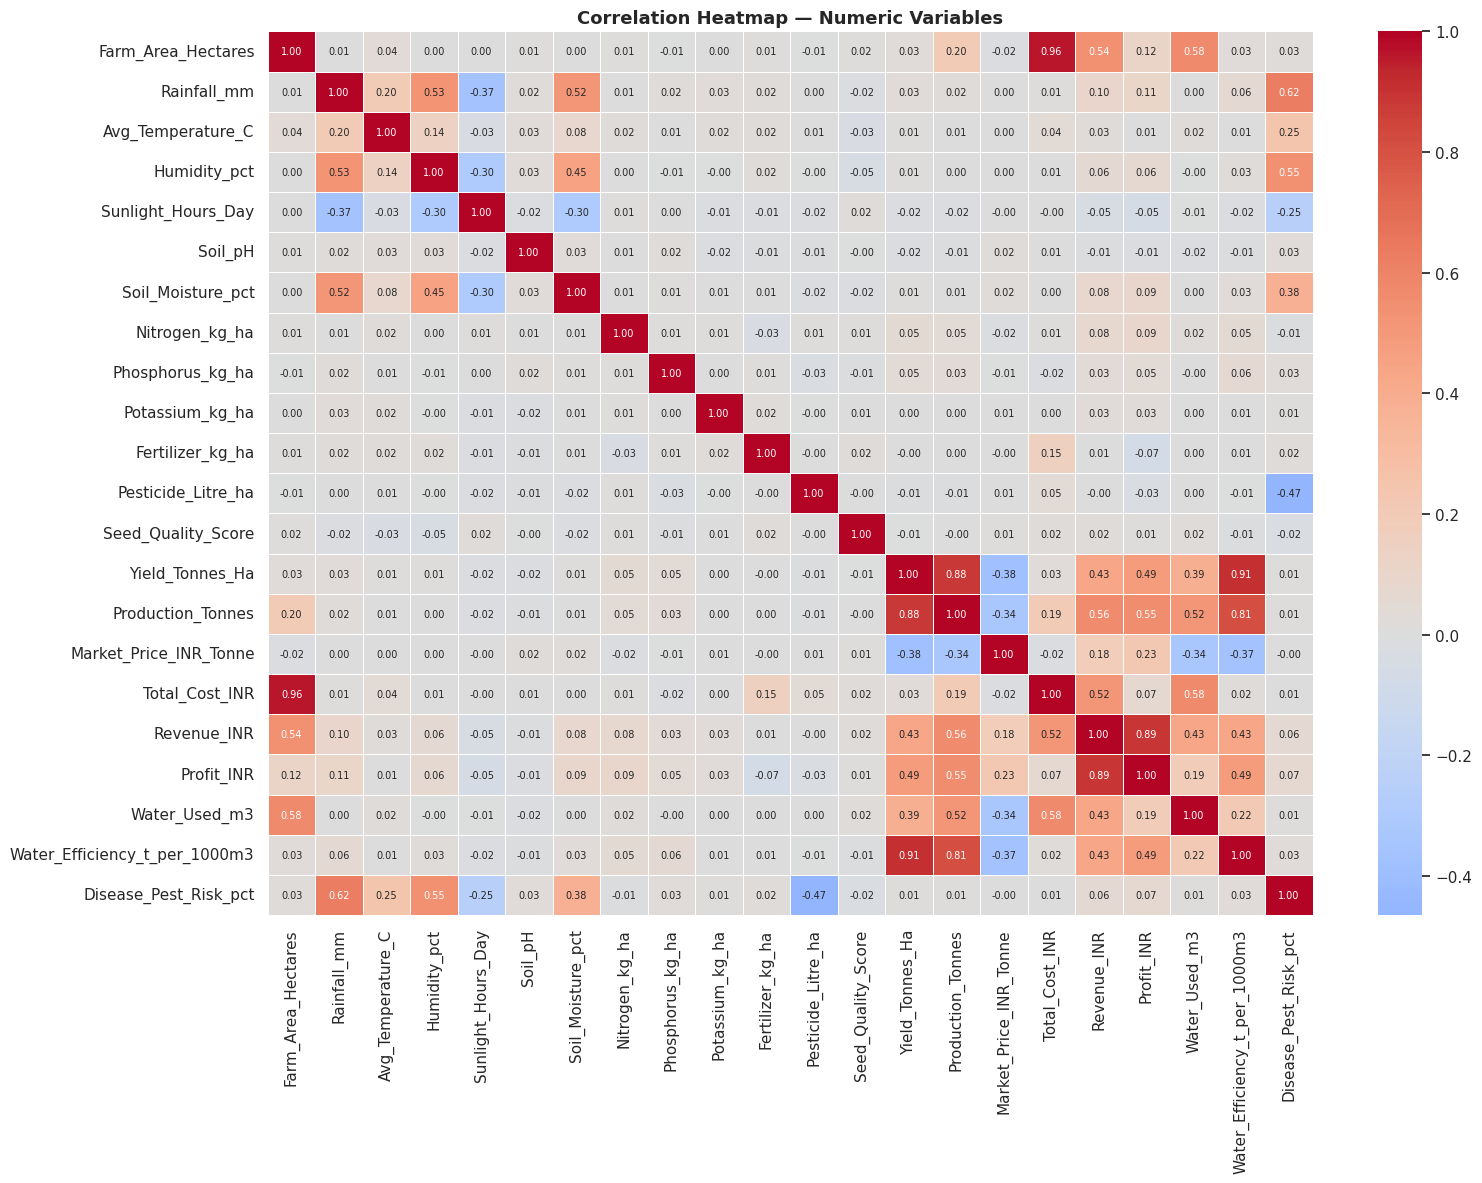

In [103]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.4, annot_kws={"size": 7})
plt.title("Correlation Heatmap — Numeric Variables")
plt.tight_layout()
plt.show()

In [104]:
print("Top correlations with Profit_INR:")
print(corr_matrix["Profit_INR"].sort_values(ascending=False).drop("Profit_INR").head(8))

print("\nTop correlations with Yield_Tonnes_Ha:")
print(corr_matrix["Yield_Tonnes_Ha"].sort_values(ascending=False).drop("Yield_Tonnes_Ha").head(8))

Top correlations with Profit_INR:
Revenue_INR                     0.89
Production_Tonnes               0.55
Water_Efficiency_t_per_1000m3   0.49
Yield_Tonnes_Ha                 0.49
Market_Price_INR_Tonne          0.23
Water_Used_m3                   0.19
Farm_Area_Hectares              0.12
Rainfall_mm                     0.11
Name: Profit_INR, dtype: float64

Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3   0.91
Production_Tonnes               0.88
Profit_INR                      0.49
Revenue_INR                     0.43
Water_Used_m3                   0.39
Nitrogen_kg_ha                  0.05
Phosphorus_kg_ha                0.05
Total_Cost_INR                  0.03
Name: Yield_Tonnes_Ha, dtype: float64


## 15. Highest and Lowest Yield and Profit Records

In [105]:
print("Highest Yield:")
print(df.loc[df["Yield_Tonnes_Ha"].idxmax(),
             ["Season", "State", "Crop", "Yield_Tonnes_Ha"]])

print("\nLowest Yield:")
print(df.loc[df["Yield_Tonnes_Ha"].idxmin(),
             ["Season", "State", "Crop", "Yield_Tonnes_Ha"]])

print("\nHighest Profit:")
print(df.loc[df["Profit_INR"].idxmax(),
             ["Season", "State", "Crop", "Profit_INR"]])

print("\nLowest Profit:")
print(df.loc[df["Profit_INR"].idxmin(),
             ["Season", "State", "Crop", "Profit_INR"]])

Highest Yield:
Season                Kharif
State                Gujarat
Crop               Sugarcane
Yield_Tonnes_Ha       101.44
Name: 1715, dtype: object

Lowest Yield:
Season                  Kharif
State              Maharashtra
Crop                     Maize
Yield_Tonnes_Ha           0.30
Name: 1, dtype: object

Highest Profit:
Season         Kharif
State          Punjab
Crop           Chilli
Profit_INR    4345421
Name: 2236, dtype: object

Lowest Profit:
Season                  Rabi
State         Andhra Pradesh
Crop               Groundnut
Profit_INR          -1019223
Name: 780, dtype: object


## 16. Seasonal Comparison Analysis

In [106]:
season_summary = df.groupby("Season")[
    ["Rainfall_mm", "Avg_Temperature_C", "Yield_Tonnes_Ha", "Profit_INR",
     "Water_Used_m3", "Water_Efficiency_t_per_1000m3", "Disease_Pest_Risk_pct"]
].agg(["mean", "median"]).round(2).loc[SEASON_ORDER]

season_summary

Rainfall_mm        Avg_Temperature_C        Yield_Tonnes_Ha        Profit_INR            Water_Used_m3           \
              mean median              mean median            mean median       mean     median          mean   median   
Season                                                                                                                   
Kharif      852.11 854.75             28.45  28.50            5.63   1.95 178,914.65  38,808.00      6,102.20 4,469.00   
Rabi        435.94 430.30             23.49  23.50            5.04   1.66  87,689.47  -3,187.00      5,846.99 4,292.00   
Zaid        299.12 283.30             31.04  31.00            4.64   1.45 -24,804.82 -62,144.00      6,419.89 4,805.00   

       Water_Efficiency_t_per_1000m3        Disease_Pest_Risk_pct         
                                mean median                  mean median  
Season                                                                    
Kharif                          5.89   3.28                 54.47  54.50  
Rabi                            5.19   2.74                 40.48  40.60  
Zaid                            4.41   2.30                 38.22  37.90

In [107]:
# Share of loss-making farms (Profit_INR < 0) by season
df["Is_Loss"] = df["Profit_INR"] < 0
loss_by_season = (df.groupby("Season")["Is_Loss"].mean() * 100).round(2).loc[SEASON_ORDER]
loss_by_season

Season
Kharif   42.21
Rabi     51.14
Zaid     64.48
Name: Is_Loss, dtype: float64

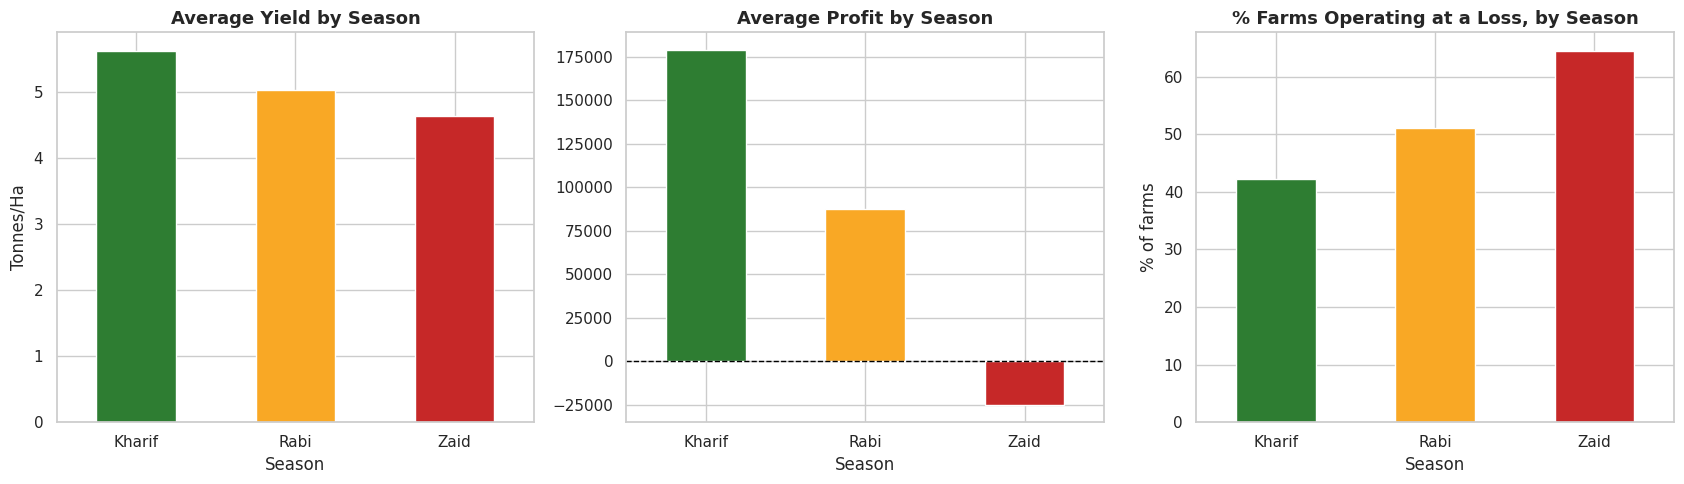

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

df.groupby("Season")["Yield_Tonnes_Ha"].mean().loc[SEASON_ORDER].plot(
    kind="bar", ax=axes[0], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[0].set_title("Average Yield by Season")
axes[0].set_ylabel("Tonnes/Ha")

df.groupby("Season")["Profit_INR"].mean().loc[SEASON_ORDER].plot(
    kind="bar", ax=axes[1], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[1].set_title("Average Profit by Season")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)

loss_by_season.plot(kind="bar", ax=axes[2], color=[SEASON_PALETTE[s] for s in SEASON_ORDER])
axes[2].set_title("% Farms Operating at a Loss, by Season")
axes[2].set_ylabel("% of farms")

for ax in axes:
    ax.set_xlabel("Season")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 17. Irrigation Method: Efficiency vs Profitability

In [109]:
irrigation_summary = df.groupby("Irrigation_Method")[
    ["Water_Used_m3", "Water_Efficiency_t_per_1000m3", "Profit_INR"]
].mean().round(2).sort_values("Water_Efficiency_t_per_1000m3", ascending=False)

irrigation_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,
Rainfed,"3,549.55",7.56,"79,050.37"
Drip,"5,918.75",6.27,"219,626.00"
Sprinkler,"6,208.26",4.67,"91,121.08"
Flood,"8,026.47",3.44,"73,354.02"


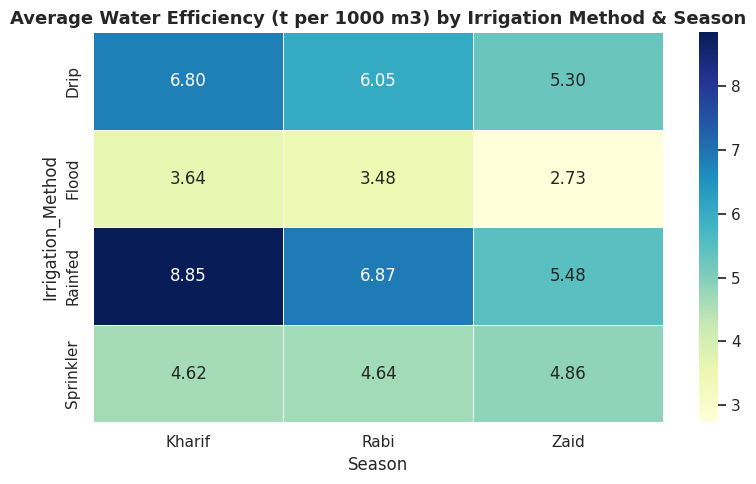

In [110]:
pivot_irr = df.pivot_table(index="Irrigation_Method", columns="Season",
                            values="Water_Efficiency_t_per_1000m3", aggfunc="mean")[SEASON_ORDER]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_irr, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Average Water Efficiency (t per 1000 m3) by Irrigation Method & Season")
plt.tight_layout()
plt.show()

## 18. State-wise Consistency of Profitability

In [111]:
state_stats = df.groupby("State")["Profit_INR"].agg(["mean", "std"]).round(0)
state_stats["Coefficient_of_Variation"] = (state_stats["std"] / state_stats["mean"]).round(2)
state_stats = state_stats.sort_values("mean", ascending=False)
state_stats

,mean,std,Coefficient_of_Variation
State,,,
Punjab,"136,026.00","599,279.00",4.41
Maharashtra,"135,429.00","584,412.00",4.32
Karnataka,"119,422.00","530,630.00",4.44
Tamil Nadu,"117,745.00","554,769.00",4.71
Gujarat,"117,568.00","571,248.00",4.86
Telangana,"108,830.00","495,138.00",4.55
Madhya Pradesh,"86,841.00","495,358.00",5.70
Andhra Pradesh,"73,454.00","524,399.00",7.14


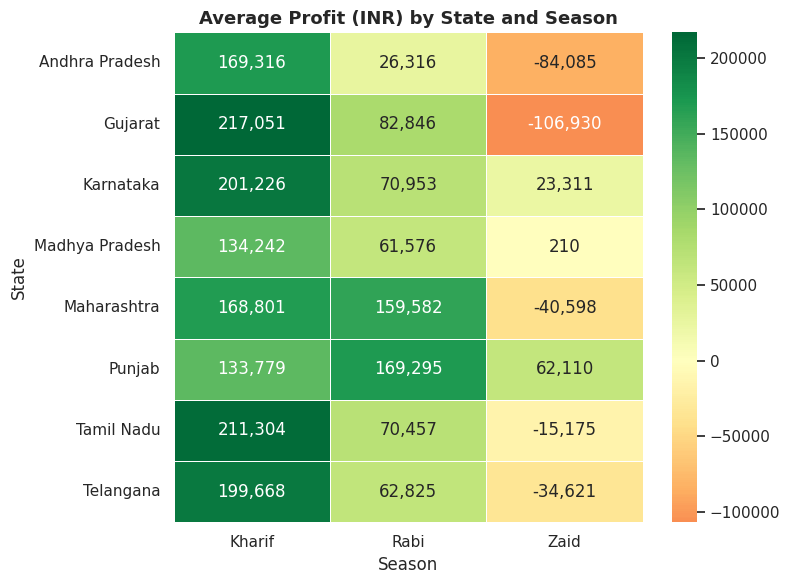

In [112]:
pivot_state = df.pivot_table(index="State", columns="Season", values="Profit_INR",
                              aggfunc="mean")[SEASON_ORDER]

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_state, annot=True, fmt=",.0f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Average Profit (INR) by State and Season")
plt.tight_layout()
plt.show()

## 19. Crop Profitability & Loss-Making Farms

*Which crops are driving profits versus losses, and how widespread is
loss-making across the dataset?*

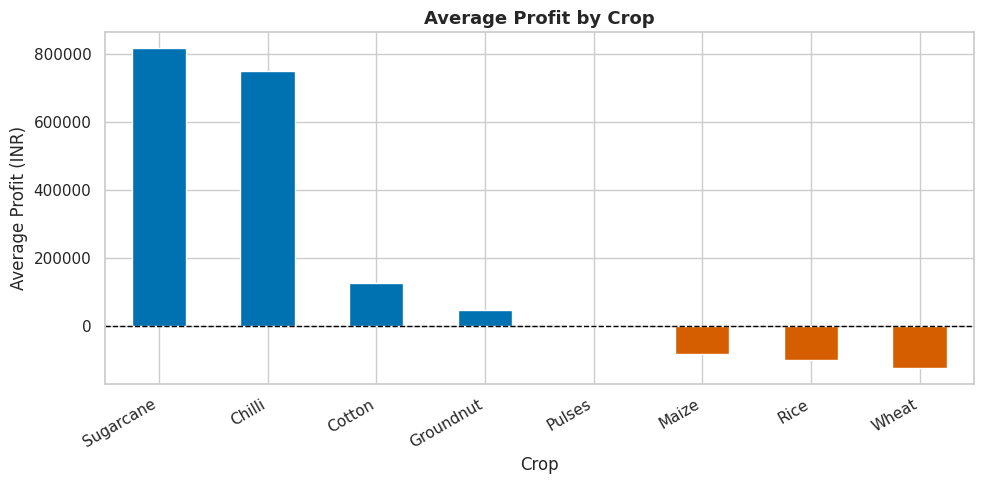

In [113]:
crop_profit = df.groupby("Crop")["Profit_INR"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ["#0072B2" if v > 0 else "#D55E00" for v in crop_profit.values]
crop_profit.plot(kind="bar", color=colors)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Average Profit by Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [114]:
loss_by_crop = (df.groupby("Crop")["Is_Loss"].mean() * 100).round(2).sort_values(ascending=False)
print(f"Overall share of farms operating at a loss: {df['Is_Loss'].mean()*100:.2f}%\n")
loss_by_crop

Overall share of farms operating at a loss: 49.15%



Crop
Wheat       74.10
Rice        66.38
Maize       63.70
Pulses      49.19
Groundnut   40.80
Cotton      34.65
Chilli      17.96
Sugarcane   11.48
Name: Is_Loss, dtype: float64

## 20. Key Insights

1. **Kharif is the dominant season** in this dataset (1,779 farms, ≈44%), followed by Rabi (1,627,      ≈41%) and Zaid (594, ≈15%) — Zaid is a comparatively minor/short growing window.
2. **Rainfall and temperature clearly track season**, as expected (Kharif ≈ 852 mm average rainfall
   vs Zaid ≈ 299 mm), confirming the dataset's seasonal environmental structure is realistic.
3. **Nearly half of all farms (≈49%) operate at a loss** (Profit_INR < 0) — this is the single
   biggest red flag in the dataset and is not confined to one crop or season.
4. **Loss-making is worst in Zaid (≈64% of farms) and best in Kharif (≈42%)** — Zaid's shorter
   season and lower rainfall appear to translate into weaker economic outcomes.
5. **Crop choice — not weather — is the dominant driver of profitability.** Sugarcane (≈₹8.2 lakh
   avg. profit) and Chilli (≈₹7.5 lakh) are highly profitable, while Wheat, Rice, Maize and
   Pulses average **at or below break-even**.
6. **Revenue_INR (r ≈ 0.89) and Water_Efficiency_t_per_1000m3 (r ≈ 0.49) correlate strongly with
   profit, while Total_Cost_INR barely does (r ≈ 0.07)** — cost is fairly uniform across farms, so
   differences in output/efficiency, not spending, separate profitable farms from unprofitable ones.
7. **Water_Efficiency_t_per_1000m3 is the strongest driver of Yield_Tonnes_Ha** (r ≈ 0.91), far
   ahead of rainfall (r ≈ 0.03) — irrigation management matters more than natural rainfall for yield.
8. **Rainfed and Drip irrigation are the most water-efficient methods**, while Flood irrigation
   is the least efficient and among the least profitable despite high water consumption.
9. **Drip irrigation shows the highest average profit** (≈₹2.2 lakh) among all irrigation methods —
   nearly 3x that of Flood irrigation.
10. **State-level performance is uneven:** Punjab and Maharashtra post the highest average profits,
    while Andhra Pradesh has both the lowest average profit and the highest profit volatility
    (coefficient of variation), suggesting the least reliable outcomes.
11. **Disease/Pest risk is higher in Kharif(≈54%) than in Rabi(≈40) or Zaid(≈38%)**, consistent
    with monsoon-season humidity, yet it shows almost no direct correlation with profit or yield —
    farmers appear to manage this risk effectively through existing practices.
12. **Market price is *negatively* correlated with yield** (r ≈ -0.38) — high-yield staple crops
    (Rice, Wheat, Maize) command lower per-tonne prices than low-yield, high-value crops
    (Sugarcane, Chilli), which is consistent with real-world crop economics.

## 21. Limitations of the Analysis

- The dataset is **cross-sectional** (a single snapshot per farm-season combination) — it does not
  track the same farm over multiple years, so year-over-year or long-term trends cannot be assessed.
- **Correlation does not imply causation.** For example, the strong yield–water-efficiency
  correlation does not by itself prove that changing irrigation method *causes* higher yield; other
  unobserved factors (soil quality, farmer experience, local infrastructure) may contribute.
- Only **8 states, 8 crops, 4 irrigation methods and 3 seasons** are represented — findings may not
  generalize to regions, crops or irrigation systems outside this dataset.
- Economic fields (`Total_Cost_INR`, `Revenue_INR`, `Market_Price_INR_Tonne`) are provided as given;
  no external validation against real market data was performed.
- A small proportion of records required imputation for `Rainfall_mm`, `Soil_Moisture_pct` and
  `Yield_Tonnes_Ha` (~1% each), which introduces minor estimation uncertainty into related results.

## 22. Final Conclusion

This analysis of 4,000 farm records confirms that **agricultural performance varies meaningfully
across seasons**, but the most consequential differences are driven less by environmental factors
like rainfall and more by **crop choice, irrigation method and water-use efficiency**. Kharif
supports the largest and comparatively most profitable set of farms, while Zaid is the smallest and
weakest-performing season, with nearly two-thirds of its farms operating at a loss. Across the
dataset as a whole, close to half of all farms are unprofitable — a finding that cuts across
seasons and points to **structural, crop-level economics** (particularly for Wheat, Rice, Maize and
Pulses) rather than isolated seasonal bad luck. Irrigation efficiency and crop selection emerge as
the two most actionable levers for improving outcomes, and the recommendations above are designed
to translate these evidence-based findings into practical seasonal agricultural planning.